# Decision tree classification #

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import metrics

In [2]:
df = read_csv("../../datasets/spambase.csv")
df.head(9)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
5,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1
6,0.00,0.00,0.00,0.0,1.92,0.00,0.00,0.00,0.00,0.64,...,0.00,0.054,0.0,0.164,0.054,0.000,1.671,4,112,1
7,0.00,0.00,0.00,0.0,1.88,0.00,0.00,1.88,0.00,0.00,...,0.00,0.206,0.0,0.000,0.000,0.000,2.450,11,49,1
8,0.15,0.00,0.46,0.0,0.61,0.00,0.30,0.00,0.92,0.76,...,0.00,0.271,0.0,0.181,0.203,0.022,9.744,445,1257,1


In [3]:
df.isnull().values.any()

False

In [4]:
df.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


In [5]:
X = df[['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',
       'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
       'char_freq_$', 'char_freq_#', 'capital_run_length_average',
       'capital_run_length_longest', 'capital_run_length_total']].values
X[:3]

array([[0.000e+00, 6.400e-01, 6.400e-01, 0.000e+00, 3.200e-01, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 6.400e-01,
        0.000e+00, 0.000e+00, 0.000e+00, 3.200e-01, 0.000e+00, 1.290e+00,
        1.930e+00, 0.000e+00, 9.600e-01, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 7.780e-01, 0.000e+00, 0.000e+00,
        3.756e+00, 6.100e+01, 2.780e+02],
       [2.100e-01, 2.800e-01, 5.000e-01, 0.000e+00, 1.400e-01, 2.800e-01,
        2.100e-01, 7.000e-02, 0.000e+00, 9.400e-01, 2.100e-01, 7.900e-01,
        6.500e-01, 2.100e-01, 1.400e-01, 1.400e-01, 7.000e-02, 2.800e-01,
        3.470e+00, 0.000e+00, 1.590e+00, 0.000e+00, 4.300e-01, 4.300e-

In [6]:
scaler = preprocessing.StandardScaler().fit(X)
X = scaler.transform(X)
X[:3]

array([[-3.42433707e-01,  3.30884903e-01,  7.12858774e-01,
        -4.68995838e-02,  1.15647106e-02, -3.50266176e-01,
        -2.91793886e-01, -2.62561558e-01, -3.23302359e-01,
        -3.71364386e-01, -2.96859527e-01,  1.14087333e-01,
        -3.12055206e-01, -1.74927167e-01, -1.90114405e-01,
         8.61714363e-02, -3.21135414e-01,  2.08120664e+00,
         1.50905374e-01, -1.67893113e-01,  1.25128398e-01,
        -1.18171509e-01, -2.90209203e-01, -2.12994388e-01,
        -3.28814669e-01, -2.99239934e-01, -2.27894812e-01,
        -2.31830156e-01, -1.66731450e-01, -2.25239518e-01,
        -1.60539307e-01, -1.43212021e-01, -1.74920257e-01,
        -1.45215148e-01, -1.98067390e-01, -2.42130222e-01,
        -3.23455613e-01, -5.98362369e-02, -1.80911344e-01,
        -1.85303849e-01, -1.20904684e-01, -1.72599962e-01,
        -2.05993114e-01, -1.27343320e-01, -2.97776209e-01,
        -1.97387481e-01, -7.13879045e-02, -1.11546231e-01,
        -1.58453362e-01, -5.14306549e-01, -1.55197675e-0

In [7]:
Y = df['spam'].values
Y[:3]

array([1, 1, 1], dtype=int64)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=5)
print("training data: ", x_train.shape, y_train.shape)
print("testing data: ", x_test.shape, y_test.shape)

training data:  (3220, 57) (3220,)
testing data:  (1381, 57) (1381,)


## Training our model ##
### change the max_depth and see the results ###

In [9]:
spamTree = DecisionTreeClassifier(criterion='entropy', max_depth=30)
spamTree.fit(x_train, y_train)
spamTree

DecisionTreeClassifier(criterion='entropy', max_depth=30)

In [10]:
predictTree = spamTree.predict(x_test)
print(predictTree[:5])
print(y_test[:5])

[0 0 0 0 0]
[0 0 0 0 0]


### The scores! ###

In [11]:
print(metrics.classification_report(y_test, predictTree))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       852
           1       0.90      0.91      0.91       529

    accuracy                           0.93      1381
   macro avg       0.92      0.92      0.92      1381
weighted avg       0.93      0.93      0.93      1381



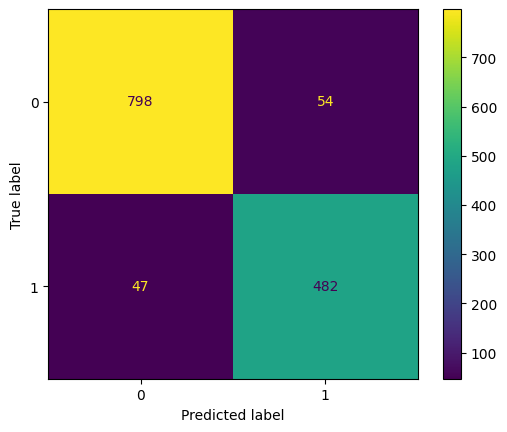

In [13]:
cm = metrics.confusion_matrix(y_test, predictTree)
disp = metrics.ConfusionMatrixDisplay(cm)
disp.plot()

## Visualize the Tree ##
### change figsize for different qualities ###

In [12]:
plt.figure(figsize=(100, 100))
plot_tree(spamTree, 
          filled=True, 
          rounded=True)
plt.show()